# Markowitz Mean-Variance Optimization — Walk-Forward Baseline

Two variants compared against QQQ Buy-and-Hold:
1. **Max Sharpe** — maximize risk-adjusted returns
2. **Min Variance** — minimize portfolio volatility

Same WFO structure as RL runs: 5yr train / 1yr test / 16 folds / OOS 2009-2025

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set working directory to Code/
SCRIPT_DIR = os.path.dirname(os.path.abspath('__file__'))
os.chdir(SCRIPT_DIR)

# Import data pipeline and markowitz functions
from functions.data_pipeline_daily import build_dataset
from markowitz import run_markowitz_wfo
from functions.baseline import compute_all_metrics

## 1. Load Data

In [2]:
DATASET = 'QQQ'

In [4]:
dataset = build_dataset(f'../../Data/{DATASET}/Outputs/Data')

DATA PIPELINE — RL Portfolio (DAILY REBALANCING)

[1/5] Loading raw data...
  Risk-free rate loaded from: ../../Data/QQQ/Outputs/Data/risk_free_data.csv
  Prices: (5836, 194)
  Mask:   (5836, 194)
  QQQ:    (5836, 1)
  VIX:    (5836, 1)

[2/5] Cleaning & aligning (daily)...
  Tickers:       194
  Trading days:  5836
  Date range:    2003-01-02 → 2026-03-13
  Close coverage: 100.0% mean, 100.0% min

[3/5] Building per-asset features (13 features)...
  Features per asset:  13
  Feature names:       ['bb_pctb', 'beta_qqq', 'dist_high_20', 'macd_hist', 'mean_rev_20', 'raw_ret_20d', 'ret_1d', 'ret_20d', 'ret_5d', 'ret_60d', 'rsi_14', 'rvol_20d', 'rvol_5d']
  Total columns:       2522

[4/5] Building global features (9 features)...
  Global features: ['vix_level', 'vix_change_5d', 'market_ret_1d', 'market_rvol_5d', 'dow', 'market_breadth', 'qqq_ret_5d', 'qqq_ret_20d', 'cross_disp']

[5/5] Applying warmup period (60 days)...
  Valid range:    2003-03-31 → 2026-03-13
  Valid days:     5776
  P

## 2. Run Markowitz Max Sharpe (WFO)

In [5]:
results_sharpe = run_markowitz_wfo(
    dataset,
    variant='max_sharpe',
    train_months=60,
    val_months=12,
    test_months=12,
    step_months=12,
    rebalance_freq_days=21,   # monthly rebalancing
    max_weight=0.10,          # max 10% per stock
    top_k=20,                 # same as RL runs
    transaction_cost_bps=2.0, # same as RL runs
    annualization=252,
    verbose=True,
)


MARKOWITZ MAX_SHARPE — Walk-Forward Optimization
  Folds: 17
  Train: 60mo | Test: 12mo | Step: 12mo
  Rebalance: every 21 trading days
  Max weight: 10% | Top-k: 20
  TC: 2.0bps | Annualization: 252

  Fold 1/17: Train 2003-03-31→2008-03-28 | Test 2009-03-31→2010-03-30
    20 stocks | Top-3: COST 10.0%, TEVA 10.0%, BB 10.0%
    → MKZ ARC: +35.8% | QQQ ARC: +60.7% ✗

  Fold 2/17: Train 2004-03-31→2009-03-30 | Test 2010-03-31→2011-03-30
    20 stocks | Top-3: AMZN 10.0%, CHKP 10.0%, BB 10.0%
    → MKZ ARC: +29.3% | QQQ ARC: +20.2% ✓

  Fold 3/17: Train 2005-03-31→2010-03-30 | Test 2011-03-31→2012-03-30
    20 stocks | Top-3: INTU 10.0%, BIIB 10.0%, FAST 10.0%
    → MKZ ARC: +18.8% | QQQ ARC: +18.8% ✓

  Fold 4/17: Train 2006-03-31→2011-03-30 | Test 2012-04-02→2013-03-28
    20 stocks | Top-3: BIIB 10.0%, CMCSA 10.0%, VRTX 10.0%
    → MKZ ARC: +23.4% | QQQ ARC: +2.4% ✓

  Fold 5/17: Train 2007-04-02→2012-03-30 | Test 2013-04-01→2014-03-28
    20 stocks | Top-3: AAPL 10.0%, CHKP 10.0%, F

## 3. Run Markowitz Min Variance (WFO)

In [6]:
results_minvar = run_markowitz_wfo(
    dataset,
    variant='min_variance',
    train_months=60,
    val_months=12,
    test_months=12,
    step_months=12,
    rebalance_freq_days=21,
    max_weight=0.10,
    top_k=20,
    transaction_cost_bps=2.0,
    annualization=252,
    verbose=True,
)


MARKOWITZ MIN_VARIANCE — Walk-Forward Optimization
  Folds: 17
  Train: 60mo | Test: 12mo | Step: 12mo
  Rebalance: every 21 trading days
  Max weight: 10% | Top-k: 20
  TC: 2.0bps | Annualization: 252

  Fold 1/17: Train 2003-03-31→2008-03-28 | Test 2009-03-31→2010-03-30
    20 stocks | Top-3: CMCSA 10.0%, AMGN 10.0%, COST 10.0%
    → MKZ ARC: +32.8% | QQQ ARC: +60.7% ✗

  Fold 2/17: Train 2004-03-31→2009-03-30 | Test 2010-03-31→2011-03-30
    20 stocks | Top-3: CHKP 10.0%, CTAS 10.0%, INTU 10.0%
    → MKZ ARC: +29.5% | QQQ ARC: +20.2% ✓

  Fold 3/17: Train 2005-03-31→2010-03-30 | Test 2011-03-31→2012-03-30
    20 stocks | Top-3: INTU 10.0%, INTC 10.0%, CSCO 10.0%
    → MKZ ARC: +34.9% | QQQ ARC: +18.8% ✓

  Fold 4/17: Train 2006-03-31→2011-03-30 | Test 2012-04-02→2013-03-28
    20 stocks | Top-3: BIIB 10.0%, CMCSA 10.0%, CHKP 10.0%
    → MKZ ARC: +23.6% | QQQ ARC: +2.4% ✓

  Fold 5/17: Train 2007-04-02→2012-03-30 | Test 2013-04-01→2014-03-28
    20 stocks | Top-3: AAPL 10.0%, GEN 10

## 4. Comparison Table

In [7]:
# Build comparison DataFrame
metrics_list = []
for name, res in [('Max Sharpe', results_sharpe), ('Min Variance', results_minvar)]:
    row = {'Strategy': name}
    row.update(res['metrics'])
    metrics_list.append(row)

# Add QQQ
qqq_row = {'Strategy': 'QQQ Buy-and-Hold'}
qqq_row.update(results_sharpe['qqq_metrics'])
metrics_list.append(qqq_row)

comparison = pd.DataFrame(metrics_list).set_index('Strategy')
cols = ['ARC (%)', 'ASD (%)', 'Max Drawdown (%)', 'MLD (years)', 
        'IR1', 'IR2', 'Sharpe', 'Sortino', 'Calmar']
print(comparison[cols].round(4).to_string())

                  ARC (%)  ASD (%)  Max Drawdown (%)  MLD (years)     IR1     IR2  Sharpe  Sortino  Calmar
Strategy                                                                                                  
Max Sharpe        21.4275  22.0537           35.1682       2.0476  0.9716  0.5920  0.9877   1.3311  0.6093
Min Variance      16.6463  19.1794           30.9991       1.6667  0.8679  0.4661  0.8978   1.1997  0.5370
QQQ Buy-and-Hold  20.4250  20.5585           34.3044       1.9524  0.9935  0.5915  1.0058   1.2979  0.5954


## 5. Equity Curves

FileNotFoundError: [Errno 2] No such file or directory: '../Results_Daily/markowitz_equity_curves.png'

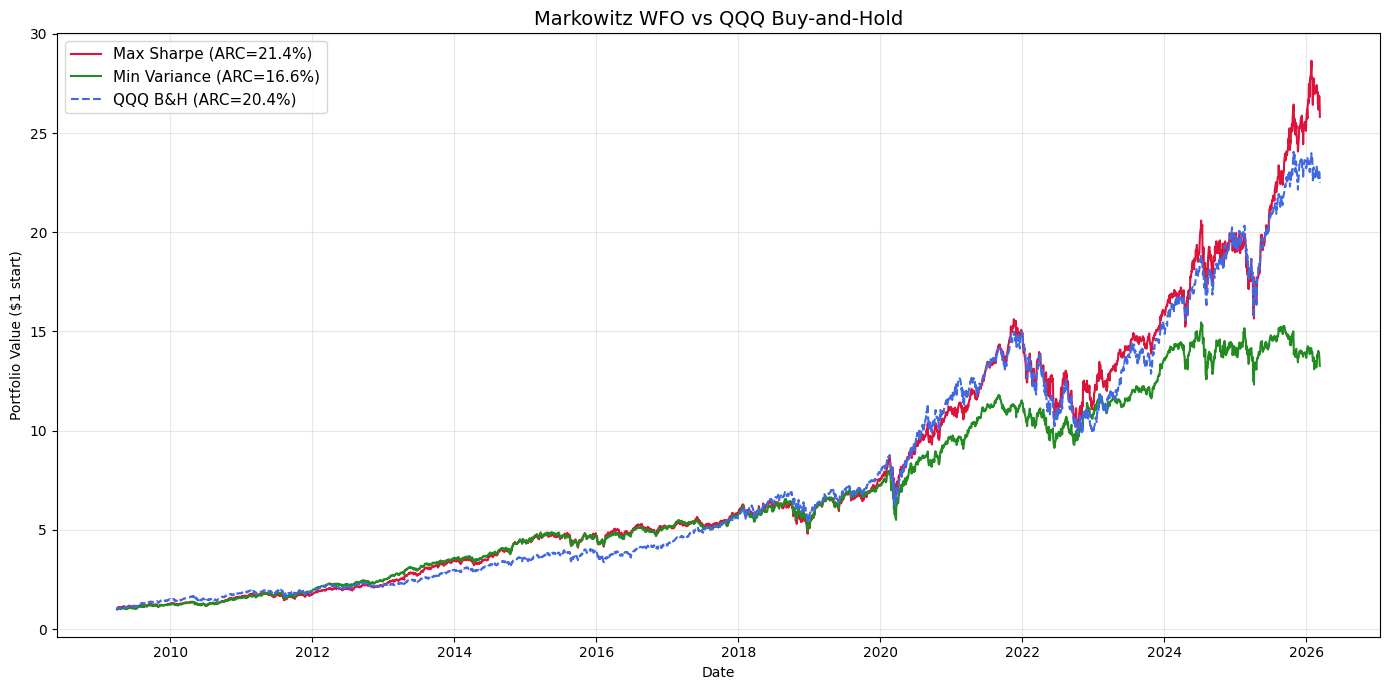

In [8]:
fig, ax = plt.subplots(figsize=(14, 7))

# Max Sharpe
dates_sharpe = results_sharpe['daily_returns'].index
ax.plot(dates_sharpe, results_sharpe['equity'][1:] / results_sharpe['equity'][1] * 
        results_sharpe['equity'][0], 
        label=f"Max Sharpe (ARC={results_sharpe['metrics']['ARC (%)']:.1f}%)",
        linewidth=1.5, color='crimson')

# Min Variance  
dates_minvar = results_minvar['daily_returns'].index
ax.plot(dates_minvar, results_minvar['equity'][1:] / results_minvar['equity'][1] *
        results_minvar['equity'][0],
        label=f"Min Variance (ARC={results_minvar['metrics']['ARC (%)']:.1f}%)",
        linewidth=1.5, color='forestgreen')

# QQQ
ax.plot(dates_sharpe, results_sharpe['qqq_equity'][1:] / results_sharpe['qqq_equity'][1] *
        results_sharpe['qqq_equity'][0],
        label=f"QQQ B&H (ARC={results_sharpe['qqq_metrics']['ARC (%)']:.1f}%)",
        linewidth=1.5, color='royalblue', linestyle='--')

ax.set_title('Markowitz WFO vs QQQ Buy-and-Hold', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value ($1 start)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot in the same folder as this notebook
from pathlib import Path

repo_root = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / ".git").exists() and (candidate / "v1_Changes_Calculations").exists():
        repo_root = candidate
        break
if repo_root is None:
    raise FileNotFoundError("Could not locate repository root for plot export.")

plot_out = repo_root / "v1_Changes_Calculations" / "Benchmark_Markowitz" / "markowitz_equity_curves.png"
plt.savefig(plot_out, dpi=150)
print(f"Saved plot: {plot_out}")
plt.show()

## 7. Save Results

In [10]:
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "Data").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root for Markowitz exports.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())

# Save in the same folder as this notebook
OUT_DIR = REPO_ROOT / "v1_Changes_Calculations" / "Benchmark_Markowitz"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Dataset label mapping (data folder -> output label)
ALL_DATASETS = ["QQQ", "NKSY", "EUSTX"]
DATASET_LABEL = {"QQQ": "QQQ", "NKSY": "NKY", "EUSTX": "EUSTX"}

all_equity_frames = []

for ds in ALL_DATASETS:
    print(f"\nRunning and saving equity lines for dataset: {ds}")

    ds_data = build_dataset(str(REPO_ROOT / "Data" / ds / "Outputs" / "Data"))

    ds_sharpe = run_markowitz_wfo(
        ds_data,
        variant='max_sharpe',
        train_months=60,
        val_months=12,
        test_months=12,
        step_months=12,
        rebalance_freq_days=21,
        max_weight=0.10,
        top_k=20,
        transaction_cost_bps=2.0,
        annualization=252,
        verbose=True,
    )

    ds_minvar = run_markowitz_wfo(
        ds_data,
        variant='min_variance',
        train_months=60,
        val_months=12,
        test_months=12,
        step_months=12,
        rebalance_freq_days=21,
        max_weight=0.10,
        top_k=20,
        transaction_cost_bps=2.0,
        annualization=252,
        verbose=True,
    )

    ds_label = DATASET_LABEL[ds]

    ds_eq_df = pd.DataFrame({
        f'{ds_label}_Max Sharpe': ds_sharpe['daily_returns'],
        f'{ds_label}_Min Variance': ds_minvar['daily_returns'],
        f'{ds_label}_QQQ': ds_sharpe['qqq_returns'],
    })

    # Per-dataset file
    per_dataset_path = OUT_DIR / f"markowitz_daily_returns_{ds_label}.csv"
    ds_eq_df.to_csv(per_dataset_path)

    # For combined all-datasets file
    tmp = ds_eq_df.copy()
    tmp.columns = pd.MultiIndex.from_product([[ds_label], tmp.columns])
    all_equity_frames.append(tmp)

    print(f"Saved: {per_dataset_path}")

# Combined all-datasets equity lines
if all_equity_frames:
    combined_df = pd.concat(all_equity_frames, axis=1)
    combined_path = OUT_DIR / "markowitz_daily_returns_all_datasets.csv"
    combined_df.to_csv(combined_path)
    print(f"Saved: {combined_path}")

print(f"\nAll Markowitz equity lines saved to: {OUT_DIR}")


Running and saving equity lines for dataset: QQQ
DATA PIPELINE — RL Portfolio (DAILY REBALANCING)

[1/5] Loading raw data...
  Risk-free rate loaded from: /Users/kamilkashif/Documents/University/Masters Thesis/MS-Thesis-Deep-RL-KK/Data/QQQ/Outputs/Data/risk_free_data.csv
  Prices: (5836, 194)
  Mask:   (5836, 194)
  QQQ:    (5836, 1)
  VIX:    (5836, 1)

[2/5] Cleaning & aligning (daily)...
  Tickers:       194
  Trading days:  5836
  Date range:    2003-01-02 → 2026-03-13
  Close coverage: 100.0% mean, 100.0% min

[3/5] Building per-asset features (13 features)...
  Features per asset:  13
  Feature names:       ['bb_pctb', 'beta_qqq', 'dist_high_20', 'macd_hist', 'mean_rev_20', 'raw_ret_20d', 'ret_1d', 'ret_20d', 'ret_5d', 'ret_60d', 'rsi_14', 'rvol_20d', 'rvol_5d']
  Total columns:       2522

[4/5] Building global features (9 features)...
  Global features: ['vix_level', 'vix_change_5d', 'market_ret_1d', 'market_rvol_5d', 'dow', 'market_breadth', 'qqq_ret_5d', 'qqq_ret_20d', 'cros

/Users/kamilkashif/miniforge3/envs/RL_MS_Thesis/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/Users/kamilkashif/miniforge3/envs/RL_MS_Thesis/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


  Features per asset:  13
  Feature names:       ['bb_pctb', 'beta_qqq', 'dist_high_20', 'macd_hist', 'mean_rev_20', 'raw_ret_20d', 'ret_1d', 'ret_20d', 'ret_5d', 'ret_60d', 'rsi_14', 'rvol_20d', 'rvol_5d']
  Total columns:       3458

[4/5] Building global features (9 features)...
  Global features: ['vix_level', 'vix_change_5d', 'market_ret_1d', 'market_rvol_5d', 'dow', 'market_breadth', 'qqq_ret_5d', 'qqq_ret_20d', 'cross_disp']

[5/5] Applying warmup period (60 days)...
  Valid range:    2003-03-27 → 2026-03-13
  Valid days:     5696
  Per-asset NaN:  21.231%
  Global NaN:     0.000%
  Avg risk-free:  1.68% annualized

PIPELINE COMPLETE (DAILY MODE)

MARKOWITZ MAX_SHARPE — Walk-Forward Optimization
  Folds: 17
  Train: 60mo | Test: 12mo | Step: 12mo
  Rebalance: every 21 trading days
  Max weight: 10% | Top-k: 20
  TC: 2.0bps | Annualization: 252

  Fold 1/17: Train 2003-03-27→2008-03-26 | Test 2009-03-27→2010-03-26
    20 stocks | Top-3: 8766.T 10.0%, 5631.T 5.5%, 5713.T 5.1%
    

/Users/kamilkashif/miniforge3/envs/RL_MS_Thesis/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/Users/kamilkashif/miniforge3/envs/RL_MS_Thesis/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


    20 stocks | Top-3: 6976.T 10.0%, 3086.T 10.0%, 9301.T 10.0%
    → MKZ ARC: +31.6% | QQQ ARC: +34.2% ✗

  Fold 7/17: Train 2009-03-27→2014-03-26 | Test 2015-03-27→2016-03-25
    20 stocks | Top-3: 4452.T 10.0%, 6508.T 10.0%, 4506.T 10.0%
    → MKZ ARC: -6.5% | QQQ ARC: -12.2% ✓

  Fold 8/17: Train 2010-03-29→2015-03-26 | Test 2016-03-28→2017-03-24
    20 stocks | Top-3: 2269.T 10.0%, 4507.T 10.0%, 4452.T 10.0%
    → MKZ ARC: +12.2% | QQQ ARC: +12.9% ✗

  Fold 9/17: Train 2011-03-28→2016-03-25 | Test 2017-03-27→2018-03-26
    20 stocks | Top-3: 7951.T 10.0%, 6703.T 10.0%, 9766.T 10.0%
    → MKZ ARC: +1.5% | QQQ ARC: +9.2% ✗

  Fold 10/17: Train 2012-03-27→2017-03-24 | Test 2018-03-27→2019-03-26
    20 stocks | Top-3: 6506.T 10.0%, 4042.T 10.0%, 6770.T 10.0%
    → MKZ ARC: -15.7% | QQQ ARC: +0.5% ✗

  Fold 11/17: Train 2013-03-27→2018-03-26 | Test 2019-03-27→2020-03-26
    20 stocks | Top-3: 4568.T 10.0%, 3436.T 10.0%, 4911.T 10.0%
    → MKZ ARC: -4.8% | QQQ ARC: -13.3% ✓

  Fold 12/1

/Users/kamilkashif/miniforge3/envs/RL_MS_Thesis/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/Users/kamilkashif/miniforge3/envs/RL_MS_Thesis/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


  Features per asset:  13
  Feature names:       ['bb_pctb', 'beta_qqq', 'dist_high_20', 'macd_hist', 'mean_rev_20', 'raw_ret_20d', 'ret_1d', 'ret_20d', 'ret_5d', 'ret_60d', 'rsi_14', 'rvol_20d', 'rvol_5d']
  Total columns:       1027

[4/5] Building global features (9 features)...
  Global features: ['vix_level', 'vix_change_5d', 'market_ret_1d', 'market_rvol_5d', 'dow', 'market_breadth', 'qqq_ret_5d', 'qqq_ret_20d', 'cross_disp']

[5/5] Applying warmup period (60 days)...
  Valid range:    2003-03-27 → 2026-03-13
  Valid days:     5901
  Per-asset NaN:  39.797%
  Global NaN:     0.008%
  Avg risk-free:  1.67% annualized

PIPELINE COMPLETE (DAILY MODE)

MARKOWITZ MAX_SHARPE — Walk-Forward Optimization
  Folds: 17
  Train: 60mo | Test: 12mo | Step: 12mo
  Rebalance: every 21 trading days
  Max weight: 10% | Top-k: 20
  TC: 2.0bps | Annualization: 252

  Fold 1/17: Train 2003-03-27→2008-03-26 | Test 2009-03-27→2010-03-26
    20 stocks | Top-3: ENI.MI 10.0%, BN.PA 10.0%, BAS.DE 10.0%
   

/Users/kamilkashif/miniforge3/envs/RL_MS_Thesis/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/Users/kamilkashif/miniforge3/envs/RL_MS_Thesis/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


    20 stocks | Top-3: DTE.DE 10.0%, DG.PA 10.0%, VIV.PA 10.0%
    → MKZ ARC: +2.0% | QQQ ARC: +12.8% ✗

  Fold 10/17: Train 2012-03-27→2017-03-24 | Test 2018-03-27→2019-03-26
    20 stocks | Top-3: ALV.DE 10.0%, ASML.AS 10.0%, DG.PA 10.0%
    → MKZ ARC: +8.8% | QQQ ARC: -5.3% ✓

  Fold 11/17: Train 2013-03-27→2018-03-26 | Test 2019-03-27→2020-03-26
    20 stocks | Top-3: ASML.AS 10.0%, MC.PA 10.0%, ALV.DE 10.0%
    → MKZ ARC: -2.9% | QQQ ARC: -13.5% ✓

  Fold 12/17: Train 2014-03-27→2019-03-26 | Test 2020-03-27→2021-03-26
    20 stocks | Top-3: DG.PA 10.0%, ALV.DE 10.0%, IBE.MC 10.0%
    → MKZ ARC: +48.5% | QQQ ARC: +53.9% ✗

  Fold 13/17: Train 2015-03-27→2020-03-26 | Test 2021-03-29→2022-03-25
    20 stocks | Top-3: IBE.MC 10.0%, DG.PA 10.0%, MC.PA 10.0%
    → MKZ ARC: -1.2% | QQQ ARC: -4.8% ✓

  Fold 14/17: Train 2016-03-29→2021-03-26 | Test 2022-03-28→2023-03-24
    20 stocks | Top-3: VOW3.DE 10.0%, PHIA.AS 10.0%, DHL.DE 10.0%
    → MKZ ARC: +4.2% | QQQ ARC: +6.9% ✗

  Fold 15/17:

/var/folders/zd/yhfq_ps96033lyz86hzc79cm0000gn/T/ipykernel_35186/1183638857.py:79: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined_df = pd.concat(all_equity_frames, axis=1)
